In [24]:
from LC_utility import *
from pdastro import *

In [35]:
from scipy.signal import convolve


In [25]:
lcpath = '../emcee_fitting/LC_tables/models/'

#lcpath = './emcee_fitting/LC_tables/models/seperate_fit/' # path mcmc fit seperatelatey each bands, keep tshift same

# new model using MCMC
LCm2_i = pd.read_csv(lcpath +'iLC_mod2.csv')
LCm2_g = pd.read_csv(lcpath +'gLC_mod2.csv')
LCm2_r = pd.read_csv(lcpath +'rLC_mod2.csv')
LCm2_z = pd.read_csv(lcpath +'zLC_mod2.csv')

LCdat2_i = pd.read_csv(lcpath +'iLC_data2.csv')
LCdat2_g = pd.read_csv(lcpath +'gLC_data2.csv')
LCdat2_r = pd.read_csv(lcpath +'rLC_data2.csv')
LCdat2_z = pd.read_csv(lcpath +'zLC_data2.csv')


In [26]:
LCm2_i

,mjd,muJyas2,muJyas2_err,phase
0,53130.276704,16.901966,0.310985,-4314.005002
1,53132.779027,16.876752,0.298429,-4311.502678
2,53135.281350,16.851527,0.286629,-4309.000355
3,53137.783673,16.826319,0.275605,-4306.498032
4,53140.285996,16.801153,0.265371,-4303.995709
...,...,...,...,...
4995,65629.380522,-1.459572,0.116457,8185.098817
4996,65631.882845,-1.455775,0.124145,8187.601140
4997,65634.385168,-1.451644,0.132833,8190.103463
4998,65636.887491,-1.447244,0.142492,8192.605786


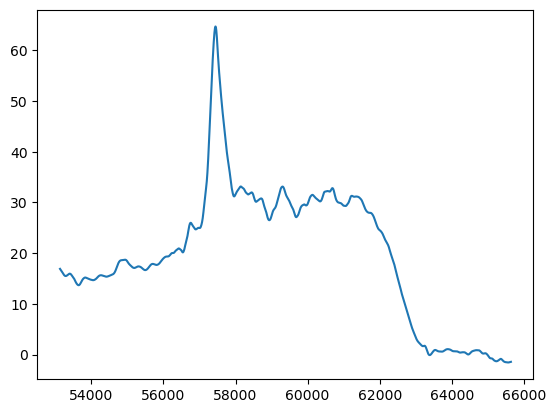

In [29]:
x = LCm2_i.mjd
y = LCm2_i.muJyas2

plt.plot(x, y, )

In [36]:
# Define a Gaussian kernel
def gaussian_kernel(size, sigma):
    x = np.linspace(-size / 2, size / 2, size)
    kernel = np.exp(-x**2 / (2 * sigma**2)) 
    return kernel / kernel.sum()   # normalize


Text(0, 0.5, 'flux')

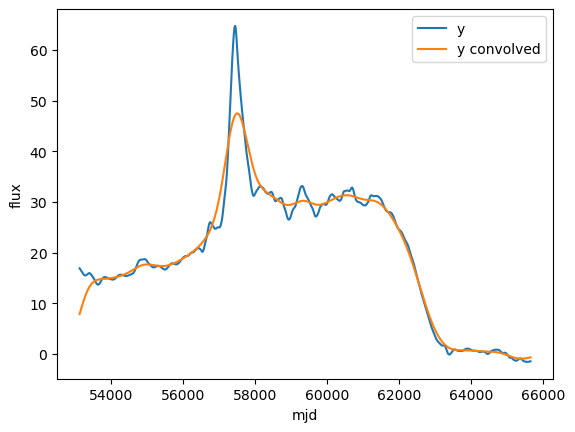

In [55]:
# Parameters for the Gaussian kernel
kernel_size = 500
sigma = 100

# Generate the Gaussian kernel
gaussian = gaussian_kernel(kernel_size, sigma)

y_convolved = convolve(y, gaussian, mode='same')


plt.plot(x, y, linestyle='-', label="y")

plt.plot(x, y_convolved, linestyle='-', label=f"y convolved")

plt.legend()

plt.xlabel('mjd')
plt.ylabel('flux')